# Mutual Fund Performance Analytics

This notebook computes returns, CAGR, Sharpe/Sortino, CAPM-style OLS alpha and beta, maximum drawdown, a weighted scorecard, and benchmark tracking error from the cleaned Day 2 files.

## Method and coverage

- The cleaned NAV file includes forward-filled calendar dates. To avoid treating weekends/holidays as zero-return observations in 252-day annualization, daily returns are computed on the 1,150 source market dates shared by NIFTY50 and NAV history.
- Data runs from 2022-01-03 to 2026-05-29. Consequently, one- and three-year CAGR are computed using the latest observation on/before each target start date; five-year CAGR is **NA** because the data has no five-year lookback.
- Annual risk-free rate is 6.5%, converted to an effective daily rate as `(1 + 0.065) ** (1 / 252) - 1`. Sharpe uses sample standard deviation of daily excess returns and `sqrt(252)`. Sortino uses sample standard deviation of negative daily excess returns and the same annualization.
- Alpha and beta are ordinary least-squares regression of daily fund returns on daily NIFTY100 returns; annualized alpha is intercept times 252. This follows the requested raw-return regression, not excess-return CAPM alpha.
- Score component ranks are percentile ranks oriented so higher values are better. Thus lower expense ratios and less-negative drawdowns receive higher ranks. Score is the weighted sum on a 0–100 scale.
- Benchmark chart rebases the top five score-ranked funds, NIFTY50 and NIFTY100 to 100 at the first common date of the latest available three-year window. Tracking error is sample standard deviation of daily active returns times `sqrt(252)`.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import linregress

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data' / 'processed'
REPORT_DIR = ROOT / 'reports'
CHART_DIR = REPORT_DIR / 'charts'
CHART_DIR.mkdir(parents=True, exist_ok=True)

funds = pd.read_csv(DATA_DIR / '01_fund_master.csv')
nav = pd.read_csv(DATA_DIR / '02_nav_history.csv', parse_dates=['date'])
benchmarks = pd.read_csv(DATA_DIR / '10_benchmark_indices.csv', parse_dates=['date'])
nav = nav.sort_values(['amfi_code', 'date']).drop_duplicates(['amfi_code', 'date'], keep='last')
assert funds.amfi_code.nunique() == 40
assert set(['NIFTY50', 'NIFTY100']).issubset(set(benchmarks.index_name))

benchmark_wide = benchmarks.pivot(index='date', columns='index_name', values='close_value').sort_index()
market_dates = benchmark_wide['NIFTY50'].dropna().index
nav_market = nav.loc[nav.date.isin(market_dates)].copy()
nav_wide = nav_market.pivot(index='date', columns='amfi_code', values='nav').sort_index()
nav_wide = nav_wide.reindex(market_dates)
if nav_wide.isna().any().any():
    missing = nav_wide.columns[nav_wide.isna().any()].tolist()
    raise ValueError(f'Missing NAV values on benchmark market dates for codes: {missing}')
if (nav_wide <= 0).any().any():
    raise ValueError('Non-positive NAV found in the aligned trading-day panel.')

daily_returns = nav_wide.pct_change(fill_method=None).dropna(how='all')
daily_returns.index.name = 'date'
fund_returns = daily_returns.loc[:, funds.amfi_code.tolist()]
benchmark_returns = benchmark_wide[['NIFTY50', 'NIFTY100']].pct_change(fill_method=None)
benchmark_returns = benchmark_returns.reindex(fund_returns.index)

coverage = {
    'funds': int(nav_wide.shape[1]),
    'market_dates': int(len(market_dates)),
    'return_observations_per_fund': int(fund_returns.notna().sum().min()),
    'nav_start': str(nav_wide.index.min().date()),
    'nav_end': str(nav_wide.index.max().date()),
    'benchmark_names': sorted(benchmarks.index_name.unique().tolist()),
}
display(pd.Series(coverage, name='value').to_frame())
display(fund_returns.describe(percentiles=[.01, .05, .5, .95, .99]).T.describe().round(5))
print('Daily-return distribution summary is across the 40 scheme-level distributions; returns use shared trading dates.')

,value
funds,40
market_dates,1150
return_observations_per_fund,1149
nav_start,2022-01-03
nav_end,2026-05-29
benchmark_names,"[BSE_SMALLCAP, CRISIL_GILT, CRISIL_LIQUID, NIF..."


,count,mean,std,min,1%,5%,50%,95%,99%,max
count,40.0,40.00000,40.00000,40.00000,40.00000,40.00000,40.00000,40.00000,40.00000,40.00000
mean,1149.0,0.00063,0.00941,-0.02988,-0.02090,-0.01471,0.00061,0.01621,0.02244,0.03257
std,0.0,0.00035,0.00421,0.01398,0.00947,0.00682,0.00036,0.00718,0.00983,0.01481
min,1149.0,0.00011,0.00031,-0.05810,-0.03707,-0.02686,-0.00007,0.00076,0.00096,0.00120
25%,1149.0,0.00027,0.00872,-0.03889,-0.02552,-0.01839,0.00032,0.01487,0.02041,0.02854
50%,1149.0,0.00065,0.00917,-0.02962,-0.02022,-0.01438,0.00059,0.01561,0.02263,0.03297
75%,1149.0,0.00088,0.01146,-0.02524,-0.01915,-0.01325,0.00093,0.01949,0.02615,0.04101
max,1149.0,0.00120,0.01625,-0.00067,-0.00051,-0.00022,0.00129,0.02833,0.03900,0.06471


Daily-return distribution summary is across the 40 scheme-level distributions; returns use shared trading dates.


## Daily return validation

Returns should be finite with small ordinary day-to-day magnitudes. The histogram and boxplot expose outliers without clipping or changing the return data.

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
0.1%        -0.039011
1%          -0.025982
5%          -0.016254
50%          0.000340
95%          0.017842
99%          0.027617
99.9%        0.039621
max          0.064713
Non-finite daily returns: 0


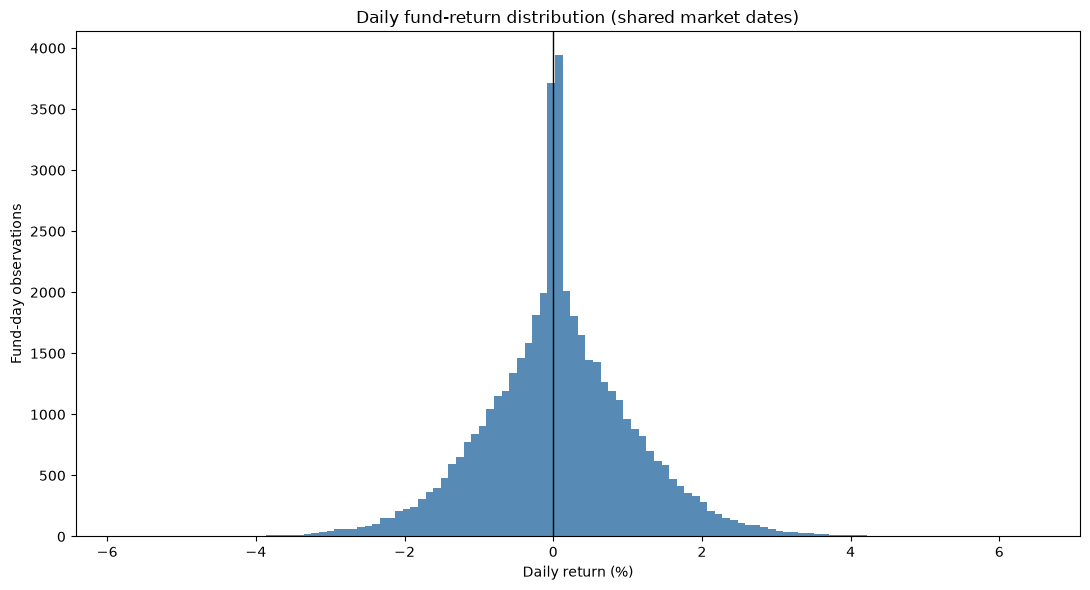

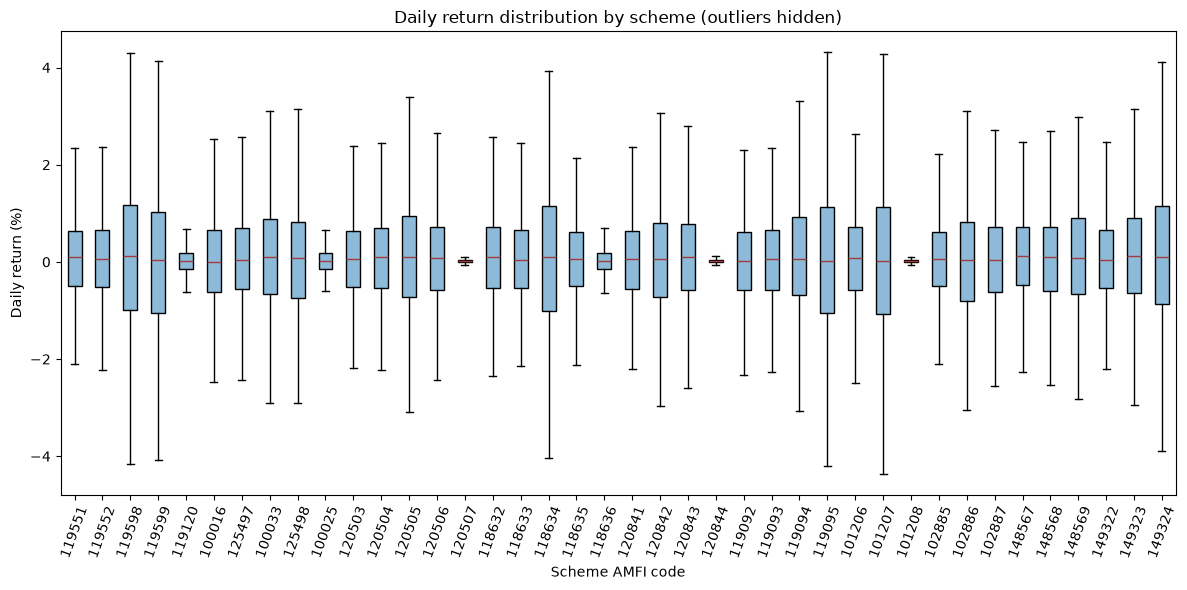

In [2]:
return_long = fund_returns.stack().rename('daily_return').reset_index()
return_summary = return_long.daily_return.describe(percentiles=[.001, .01, .05, .5, .95, .99, .999])
print(return_summary.to_string())
print('Non-finite daily returns:', int((~np.isfinite(return_long.daily_return)).sum()))
fig, ax = plt.subplots(figsize=(11, 6))
ax.hist(return_long.daily_return * 100, bins=120, color='#3977a8', alpha=.85)
ax.axvline(0, color='black', linewidth=1)
ax.set(title='Daily fund-return distribution (shared market dates)', xlabel='Daily return (%)', ylabel='Fund-day observations')
fig.tight_layout()
fig.savefig(CHART_DIR / '27_daily_return_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([fund_returns[c].dropna().to_numpy() * 100 for c in fund_returns], showfliers=False, patch_artist=True,
           boxprops={'facecolor':'#8ebad9'}, medianprops={'color':'#a23b3b'})
ax.set(title='Daily return distribution by scheme (outliers hidden)', xlabel='Scheme AMFI code', ylabel='Daily return (%)')
ax.set_xticks(range(1, len(fund_returns.columns) + 1), [str(x) for x in fund_returns.columns], rotation=70)
fig.tight_layout()
fig.savefig(CHART_DIR / '28_daily_return_by_scheme.png', dpi=180, bbox_inches='tight')
plt.show()

assert np.isfinite(fund_returns.to_numpy()).all()
assert len(return_long) == fund_returns.size
assert return_long.daily_return.abs().quantile(.999) < .25, 'Review extreme daily returns before using analytics.'

## CAGR, risk-adjusted returns, regression, and drawdown

CAGR start values use the last available NAV at or before the target anniversary, with elapsed years calculated from the actual selected dates. The 5-year output column is retained for comparability but is null when the start date predates source coverage.

In [3]:
TRADING_DAYS = 252
RISK_FREE_ANNUAL = 0.065
RISK_FREE_DAILY = (1 + RISK_FREE_ANNUAL) ** (1 / TRADING_DAYS) - 1
as_of = nav_wide.index.max()

def cagr_for_years(series: pd.Series, years: int) -> tuple[float, str | None]:
    target = as_of - pd.DateOffset(years=years)
    candidates = series.loc[series.index <= target].dropna()
    if candidates.empty:
        return np.nan, None
    start_date = candidates.index[-1]
    start_nav = float(candidates.iloc[-1])
    end_nav = float(series.loc[:as_of].dropna().iloc[-1])
    end_date = series.loc[:as_of].dropna().index[-1]
    elapsed_years = (end_date - start_date).days / 365.2425
    if start_nav <= 0 or elapsed_years <= 0:
        return np.nan, str(start_date.date())
    return (end_nav / start_nav) ** (1 / elapsed_years) - 1, str(start_date.date())

cagr_rows = []
for code in fund_returns.columns:
    row = {'amfi_code': int(code)}
    for period in (1, 3, 5):
        value, start_date = cagr_for_years(nav_wide[code], period)
        row[f'cagr_{period}yr'] = value
        row[f'cagr_{period}yr_start_date'] = start_date
    cagr_rows.append(row)
cagr_table = pd.DataFrame(cagr_rows)

fund_riskfree = fund_returns - RISK_FREE_DAILY
sharpe = fund_riskfree.mean() / fund_riskfree.std(ddof=1) * np.sqrt(TRADING_DAYS)
downside = fund_riskfree.where(fund_riskfree < 0)
downside_std = downside.std(ddof=1)
sortino = fund_riskfree.mean() / downside_std * np.sqrt(TRADING_DAYS)

nifty100_returns = benchmark_returns['NIFTY100']
alpha_beta_rows = []
for code in fund_returns.columns:
    aligned = pd.concat([fund_returns[code], nifty100_returns], axis=1, join='inner').dropna()
    if len(aligned) < 30:
        slope = intercept = r_value = p_value = std_err = np.nan
    else:
        fit = linregress(aligned.iloc[:, 1].to_numpy(), aligned.iloc[:, 0].to_numpy())
        slope, intercept, r_value, p_value, std_err = fit.slope, fit.intercept, fit.rvalue, fit.pvalue, fit.stderr
    alpha_beta_rows.append({
        'amfi_code': int(code), 'beta': slope, 'daily_alpha': intercept,
        'annualized_alpha': intercept * TRADING_DAYS,
        'regression_r_squared': r_value ** 2 if pd.notna(r_value) else np.nan,
        'regression_p_value': p_value, 'beta_std_err': std_err,
        'observations': int(len(aligned)),
    })
alpha_beta = pd.DataFrame(alpha_beta_rows)

drawdown_rows = []
for code in nav_wide.columns:
    series = nav_wide[code].dropna()
    running_peak = series.cummax()
    drawdown = series / running_peak - 1
    trough_date = drawdown.idxmin()
    peak_nav = running_peak.loc[trough_date]
    peak_date = series.loc[:trough_date][series.loc[:trough_date].eq(peak_nav)].index[-1]
    recovered = series.loc[trough_date:][series.loc[trough_date:] >= peak_nav]
    recovery_date = recovered.index[0] if not recovered.empty else pd.NaT
    drawdown_rows.append({
        'amfi_code': int(code), 'max_drawdown': float(drawdown.loc[trough_date]),
        'drawdown_peak_date': peak_date.date().isoformat(),
        'drawdown_trough_date': trough_date.date().isoformat(),
        'drawdown_recovery_date': recovery_date.date().isoformat() if pd.notna(recovery_date) else None,
        'drawdown_recovered': bool(pd.notna(recovery_date)),
    })
drawdowns = pd.DataFrame(drawdown_rows)

metrics = (funds[['amfi_code','scheme_name','fund_house','category','plan','expense_ratio_pct']]
           .merge(cagr_table, on='amfi_code', validate='one_to_one')
           .merge(drawdowns, on='amfi_code', validate='one_to_one')
           .merge(alpha_beta, on='amfi_code', validate='one_to_one'))
metrics['sharpe_ratio'] = metrics.amfi_code.map(sharpe)
metrics['sortino_ratio'] = metrics.amfi_code.map(sortino)
metrics['daily_return_mean'] = metrics.amfi_code.map(fund_returns.mean())
metrics['daily_return_std'] = metrics.amfi_code.map(fund_returns.std(ddof=1))
metrics['annual_risk_free_rate'] = RISK_FREE_ANNUAL
metrics['as_of_date'] = as_of.date().isoformat()

score_components = {
    'score_3yr_return_rank': ('cagr_3yr', True, .30),
    'score_sharpe_rank': ('sharpe_ratio', True, .25),
    'score_alpha_rank': ('annualized_alpha', True, .20),
    'score_expense_rank': ('expense_ratio_pct', False, .15),
    'score_drawdown_rank': ('max_drawdown', True, .10),
}
for output_col, (source_col, higher_is_better, _) in score_components.items():
    metrics[output_col] = metrics[source_col].rank(pct=True, ascending=higher_is_better, method='average') * 100
metrics['fund_score'] = sum(metrics[col] * weight for col, (_, _, weight) in score_components.items())
metrics['fund_score'] = metrics['fund_score'].round(2)
metrics['sharpe_rank'] = metrics['sharpe_ratio'].rank(method='min', ascending=False).astype('int64')
metrics['sortino_rank'] = metrics['sortino_ratio'].rank(method='min', ascending=False).astype('int64')
metrics = metrics.sort_values(['fund_score','scheme_name'], ascending=[False,True]).reset_index(drop=True)
metrics['score_rank'] = np.arange(1, len(metrics) + 1)

cagr_columns = ['amfi_code','scheme_name','cagr_1yr','cagr_1yr_start_date','cagr_3yr','cagr_3yr_start_date','cagr_5yr','cagr_5yr_start_date']
display(metrics[cagr_columns].head(10).style.format({'cagr_1yr':'{:.2%}','cagr_3yr':'{:.2%}','cagr_5yr':'{:.2%}'}))
display(metrics[['score_rank','amfi_code','scheme_name','fund_score','cagr_3yr','sharpe_ratio','annualized_alpha','expense_ratio_pct','max_drawdown']].head(10).style.format({'fund_score':'{:.2f}','cagr_3yr':'{:.2%}','sharpe_ratio':'{:.3f}','annualized_alpha':'{:.2%}','expense_ratio_pct':'{:.2f}%','max_drawdown':'{:.2%}'}))
worst_drawdown = drawdowns.sort_values('max_drawdown').iloc[0]
worst_fund = funds.loc[funds.amfi_code.eq(worst_drawdown.amfi_code), 'scheme_name'].iloc[0]
print(f"Worst max drawdown: {worst_fund} ({worst_drawdown.max_drawdown:.2%}), "
      f"peak {worst_drawdown.drawdown_peak_date}, trough {worst_drawdown.drawdown_trough_date}, "
      f"recovery {worst_drawdown.drawdown_recovery_date or 'not recovered by as-of date'}.")
print(f"Funds with unavailable 5-year CAGR: {int(metrics.cagr_5yr.isna().sum())} / {len(metrics)}; "
      f"NAV source begins {nav_wide.index.min():%Y-%m-%d}.")

metrics.to_csv(REPORT_DIR / 'fund_scorecard.csv', index=False)
alpha_beta_export = metrics[['amfi_code','scheme_name','fund_house','category','plan','beta','daily_alpha','annualized_alpha','regression_r_squared','regression_p_value','beta_std_err','observations']].sort_values('annualized_alpha',ascending=False)
alpha_beta_export.to_csv(REPORT_DIR / 'alpha_beta.csv', index=False)
metrics.to_csv(REPORT_DIR / 'performance_metrics.csv', index=False)
print('Saved fund_scorecard.csv, alpha_beta.csv, and performance_metrics.csv.')

,amfi_code,scheme_name,cagr_1yr,cagr_1yr_start_date,cagr_3yr,cagr_3yr_start_date,cagr_5yr,cagr_5yr_start_date
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,20.38%,2025-05-29,33.99%,2023-05-29,nan%,None
1,120505,ICICI Pru Midcap Fund - Regular - Growth,29.63%,2025-05-29,31.77%,2023-05-29,nan%,None
2,120843,Kotak Flexicap Fund - Regular - Growth,26.68%,2025-05-29,29.57%,2023-05-29,nan%,None
3,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.28%,2025-05-29,32.43%,2023-05-29,nan%,None
4,120504,ICICI Pru Bluechip Fund - Direct - Growth,13.07%,2025-05-29,32.48%,2023-05-29,nan%,None
5,119094,Axis Midcap Fund - Regular - Growth,22.28%,2025-05-29,35.10%,2023-05-29,nan%,None
6,119551,SBI Bluechip Fund - Regular Plan - Growth,60.49%,2025-05-29,30.45%,2023-05-29,nan%,None
7,148569,Mirae Asset Tax Saver Fund - Regular - Growth,39.78%,2025-05-29,29.17%,2023-05-29,nan%,None
8,101206,ABSL Frontline Equity Fund - Regular - Growth,47.96%,2025-05-29,28.96%,2023-05-29,nan%,None
9,119598,SBI Small Cap Fund - Regular Plan - Growth,82.85%,2025-05-29,26.66%,2023-05-29,nan%,None


,score_rank,amfi_code,scheme_name,fund_score,cagr_3yr,sharpe_ratio,annualized_alpha,expense_ratio_pct,max_drawdown
0,1,148567,Mirae Asset Large Cap Fund - Regular - Growth,86.25,33.99%,1.463,26.98%,1.46%,-11.27%
1,2,120505,ICICI Pru Midcap Fund - Regular - Growth,82.25,31.77%,1.191,29.26%,1.36%,-18.19%
2,3,120843,Kotak Flexicap Fund - Regular - Growth,82.00,29.57%,1.319,27.33%,1.45%,-12.97%
3,4,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,80.75,32.43%,1.104,27.20%,1.38%,-16.22%
4,5,120504,ICICI Pru Bluechip Fund - Direct - Growth,80.00,32.48%,1.041,21.19%,0.80%,-12.59%
5,6,119094,Axis Midcap Fund - Regular - Growth,77.00,35.10%,1.009,26.08%,1.38%,-20.96%
6,7,119551,SBI Bluechip Fund - Regular Plan - Growth,74.81,30.45%,1.223,23.20%,1.54%,-15.01%
7,8,148569,Mirae Asset Tax Saver Fund - Regular - Growth,73.69,29.17%,1.246,28.27%,1.60%,-16.40%
8,9,101206,ABSL Frontline Equity Fund - Regular - Growth,68.19,28.96%,1.041,21.40%,1.60%,-11.29%
9,10,119598,SBI Small Cap Fund - Regular Plan - Growth,67.38,26.66%,0.953,30.34%,1.43%,-28.71%


Worst max drawdown: SBI Small Cap Fund - Direct Plan - Growth (-52.57%), peak 2023-01-17, trough 2025-10-28, recovery nan.
Funds with unavailable 5-year CAGR: 40 / 40; NAV source begins 2022-01-03.
Saved fund_scorecard.csv, alpha_beta.csv, and performance_metrics.csv.


## Top-five funds versus NIFTY50 and NIFTY100

The comparison period is the last available three years, anchored to the latest date common to all five funds and both benchmarks. The chart uses rebased index values; a separate table reports annualized tracking error and active return.

,amfi_code,scheme_name,benchmark,tracking_error_annualized,annualized_active_return_arithmetic,observations
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.19%,37.64%,784
1,148567,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.80%,20.33%,784
2,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.84%,36.85%,784
3,120505,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.27%,19.55%,784
4,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.51%,34.67%,784
5,120843,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.65%,17.37%,784
6,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,NIFTY50,22.82%,37.20%,784
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Growth,NIFTY100,22.50%,19.89%,784
8,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,18.82%,36.59%,784
9,120504,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,18.73%,19.29%,784


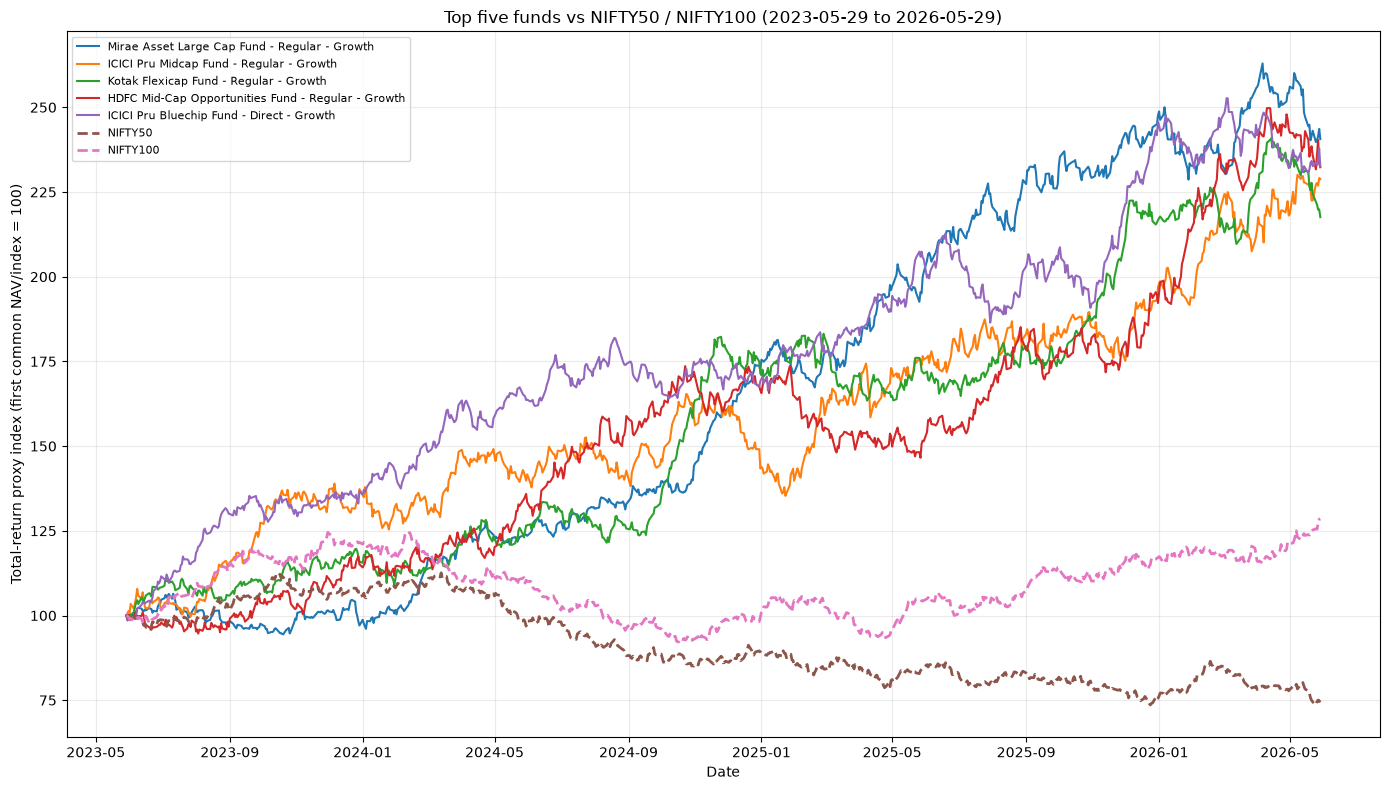

Benchmark chart saved: C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\benchmark_comparison_top5.png
Comparison sessions: 785; first date 2023-05-29; last date 2026-05-29.


In [4]:
top5 = metrics.head(5).copy()
comparison = pd.concat([nav_wide[top5.amfi_code.tolist()], benchmark_wide[['NIFTY50','NIFTY100']]], axis=1, join='inner').sort_index()
comparison = comparison.dropna()
comparison_end = comparison.index.max()
comparison_start_target = comparison_end - pd.DateOffset(years=3)
comparison = comparison.loc[comparison.index >= comparison_start_target]
if len(comparison) < 500:
    raise ValueError(f'Insufficient shared observations for a 3-year comparison: {len(comparison)}')
comparison_returns = comparison.pct_change(fill_method=None).dropna()
tracking_rows = []
for code in top5.amfi_code:
    for index_name in ('NIFTY50','NIFTY100'):
        active = comparison_returns[code] - comparison_returns[index_name]
        tracking_rows.append({
            'amfi_code': int(code),
            'scheme_name': funds.loc[funds.amfi_code.eq(code),'scheme_name'].iloc[0],
            'benchmark': index_name,
            'tracking_error_annualized': active.std(ddof=1) * np.sqrt(TRADING_DAYS),
            'annualized_active_return_arithmetic': active.mean() * TRADING_DAYS,
            'observations': int(active.count()),
        })
tracking_error = pd.DataFrame(tracking_rows)
tracking_error.to_csv(REPORT_DIR / 'benchmark_tracking_error.csv', index=False)
display(tracking_error.style.format({'tracking_error_annualized':'{:.2%}','annualized_active_return_arithmetic':'{:.2%}'}))

base = comparison.iloc[0]
rebased = comparison.divide(base).multiply(100)
labels = {code: funds.loc[funds.amfi_code.eq(code),'scheme_name'].iloc[0] for code in top5.amfi_code}
labels.update({'NIFTY50':'NIFTY50','NIFTY100':'NIFTY100'})
fig, ax = plt.subplots(figsize=(14, 8))
for column in comparison.columns:
    ax.plot(rebased.index, rebased[column], linewidth=2 if column in ('NIFTY50','NIFTY100') else 1.5,
            linestyle='--' if column in ('NIFTY50','NIFTY100') else '-', label=labels[column])
ax.set(title=f"Top five funds vs NIFTY50 / NIFTY100 ({comparison.index.min():%Y-%m-%d} to {comparison_end:%Y-%m-%d})",
       xlabel='Date', ylabel='Total-return proxy index (first common NAV/index = 100)')
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=.25)
fig.tight_layout()
benchmark_chart = REPORT_DIR / 'benchmark_comparison_top5.png'
fig.savefig(benchmark_chart, dpi=200, bbox_inches='tight')
plt.show()
print(f'Benchmark chart saved: {benchmark_chart}')
print(f'Comparison sessions: {len(comparison)}; first date {comparison.index.min():%Y-%m-%d}; last date {comparison_end:%Y-%m-%d}.')

## Final validation

The exported scorecard and regression file contain all 40 funds. Metrics retain unavailable 5-year CAGR as null rather than extrapolating beyond observed history.

In [5]:
scorecard_path = REPORT_DIR / 'fund_scorecard.csv'
alpha_beta_path = REPORT_DIR / 'alpha_beta.csv'
scorecard_check = pd.read_csv(scorecard_path)
alpha_beta_check = pd.read_csv(alpha_beta_path)
assert len(scorecard_check) == 40 and scorecard_check.amfi_code.nunique() == 40
assert len(alpha_beta_check) == 40 and alpha_beta_check.amfi_code.nunique() == 40
assert scorecard_check.fund_score.between(0,100).all()
assert scorecard_check.sharpe_rank.nunique() == 40 and set(scorecard_check.sharpe_rank) == set(range(1,41))
assert scorecard_check.cagr_5yr.isna().all(), 'With the observed source start date, 5-year CAGR should be unavailable.'
assert benchmark_chart.exists() and benchmark_chart.stat().st_size > 0
print('Validated 40 unique funds in each CSV; score range:', scorecard_check.fund_score.min(), 'to', scorecard_check.fund_score.max())
print('Five-year CAGR unavailable for all funds because the source begins in 2022; null values retained.')
print('Final output files:', scorecard_path, alpha_beta_path, REPORT_DIR / 'performance_metrics.csv', REPORT_DIR / 'benchmark_tracking_error.csv', benchmark_chart)
print('Drawdown review file details:')
display(metrics[['scheme_name','max_drawdown','drawdown_peak_date','drawdown_trough_date','drawdown_recovery_date','drawdown_recovered']].sort_values('max_drawdown').head(10))

Validated 40 unique funds in each CSV; score range: 13.69 to 86.25
Five-year CAGR unavailable for all funds because the source begins in 2022; null values retained.
Final output files: C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\fund_scorecard.csv C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\alpha_beta.csv C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\performance_metrics.csv C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\benchmark_tracking_error.csv C:\Users\nihar\OneDrive\Desktop\Mutual Funds Analysis\reports\benchmark_comparison_top5.png
Drawdown review file details:


,scheme_name,max_drawdown,drawdown_peak_date,drawdown_trough_date,drawdown_recovery_date,drawdown_recovered
34,SBI Small Cap Fund - Direct Plan - Growth,-0.525742,2023-01-17,2025-10-28,NaN,False
37,Axis Small Cap Fund - Regular - Growth,-0.516778,2025-05-22,2026-05-11,NaN,False
36,ABSL Small Cap Fund - Regular - Growth,-0.354469,2024-11-21,2026-05-11,NaN,False
11,DSP Small Cap Fund - Regular - Growth,-0.311719,2024-05-03,2025-01-03,2025-06-13,True
9,SBI Small Cap Fund - Regular Plan - Growth,-0.287060,2024-08-28,2025-05-14,2025-09-29,True
39,UTI Mid Cap Fund - Regular - Growth,-0.280011,2025-01-07,2026-04-27,NaN,False
38,HDFC Top 100 Fund - Regular Plan - Growth,-0.247344,2022-03-30,2022-09-15,2023-03-14,True
33,Kotak Emerging Equity Fund - Regular - Growth,-0.240035,2023-11-09,2024-10-17,2025-10-14,True
28,Nippon India Small Cap Fund - Regular - Growth,-0.233449,2025-04-09,2026-02-20,2026-04-15,True
22,Axis Bluechip Fund - Direct - Growth,-0.217514,2022-02-24,2023-05-22,2023-12-26,True
